In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import sys
from pathlib import Path
from src.data import Checkerboard_Dataset, TorusLieWrapper, AngleTorusWrapper, torus_embedding
from torch.utils.data import DataLoader

In [25]:
n_rows = 4
n_points = 10000
batch_size = 32

checkerboard_dataset = Checkerboard_Dataset(n_rows, n_points)


loader = DataLoader(checkerboard_dataset, batch_size=batch_size, shuffle = True)
batch = next(iter(loader))
first_sample = batch[0]
print("sample shape of checkerboard dataset", first_sample.shape)

sample shape of checkerboard dataset torch.Size([10000, 2])


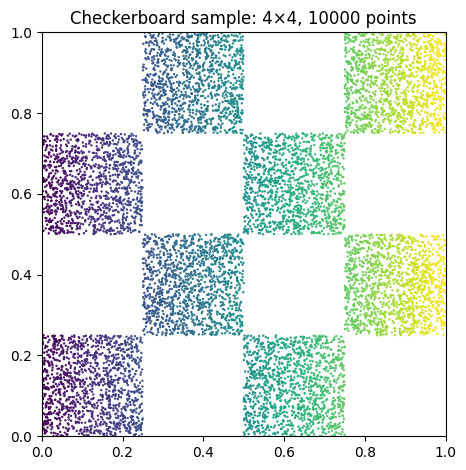

In [26]:
fig,ax = plt.subplots()
ax.scatter(first_sample[:,0],first_sample[:,1],s = 0.5, c= first_sample[:,0], cmap = "viridis")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
ax.set_title(f"Checkerboard sample: {n_rows}×{n_rows}, {n_points} points")
plt.tight_layout()
plt.show()

torch.Size([10000, 2])
torch.Size([10000, 3])


Text(0.5, 0.92, 'Checkerboard on 2d torus')

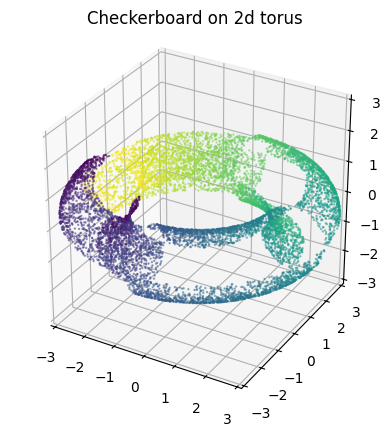

In [27]:
# Lie torus data like checkerboard
Torus_dataset = TorusLieWrapper(checkerboard_dataset)
angle_Torus_dataset = AngleTorusWrapper(Torus_dataset)
dataloader_torus = DataLoader(angle_Torus_dataset, batch_size=batch_size, shuffle=True)

batched_sample = next(iter(dataloader_torus))
sample = batched_sample[0]
print(sample.shape)
theta1 = sample[:,0]
theta2 = sample[:,1]
# using 3d torus embedding to plot the checkerboard
torusEmbedding = torus_embedding(theta1,theta2)
print(torusEmbedding.shape)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(torusEmbedding[:,0],torusEmbedding[:,1],torusEmbedding[:,2],c=theta1,cmap = "viridis", s = 0.5, alpha = 0.5)
ax.set_xlim(-np.pi,np.pi)
ax.set_ylim(-np.pi,np.pi)
ax.set_zlim(-np.pi,np.pi)
ax.set_aspect("equal")
ax.set_title("Checkerboard on 2d torus")

Text(0.5, 1.0, 'Checkerboard on -pi, pi coordinate')

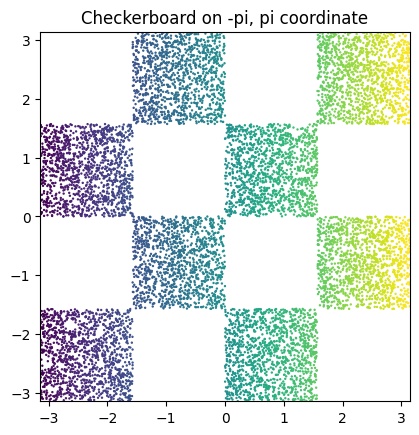

In [28]:
# plot checker board on the -pi, pi coordinate
fig,ax = plt.subplots()
ax.scatter(theta1,theta2,s = 0.5, c=theta1, cmap = "viridis")
ax.set_xlim(-np.pi,np.pi)
ax.set_ylim(-np.pi,np.pi)
ax.set_aspect("equal")
ax.set_title("Checkerboard on -pi, pi coordinate")

## Sample Forward of checkerboard dataset from TDM diffusion model.

In [29]:
import src.diffusion as diffusion
import src.sde as sde

model = diffusion.TDMDiffusion(dim = 2, integrator_type = "Euler")
n_points = 10000
checkerboard_dataset = Checkerboard_Dataset(n_rows, n_points)
matrix_dataset = TorusLieWrapper(checkerboard_dataset)
angle_Torus_dataset = AngleTorusWrapper(matrix_dataset)
dataloader_torus = DataLoader(angle_Torus_dataset, batch_size=batch_size, shuffle=True)

batched_sample = next(iter(dataloader_torus))
sample = batched_sample[0]
print(sample.shape)
theta1 = sample[:,0]
theta2 = sample[:,1]
print("shape of each batch",batched_sample.shape)
# Fixed times on the forward process
constant_t_forward = (0.1, 0.4, 0.7, 1.0, 15.0)
unconditional_samples = []
scores = []
# sample the forward process at fixed times
for i in range(len(constant_t_forward)):
    unconditional_sample_i, score_i = model.sample_forward(f0 = batched_sample, total_time = 10,t_dist_kw = "constant", constant_t = constant_t_forward[i])
    unconditional_samples.append(unconditional_sample_i)
    scores.append(score_i)
# shape: unconditional_samples: (constant_t_forward, batch_size, n_points, 2)
# shape: scores: (constant_t_forward, batch_size, n_points, 2)

torch.Size([10000, 2])
shape of each batch torch.Size([32, 10000, 2])


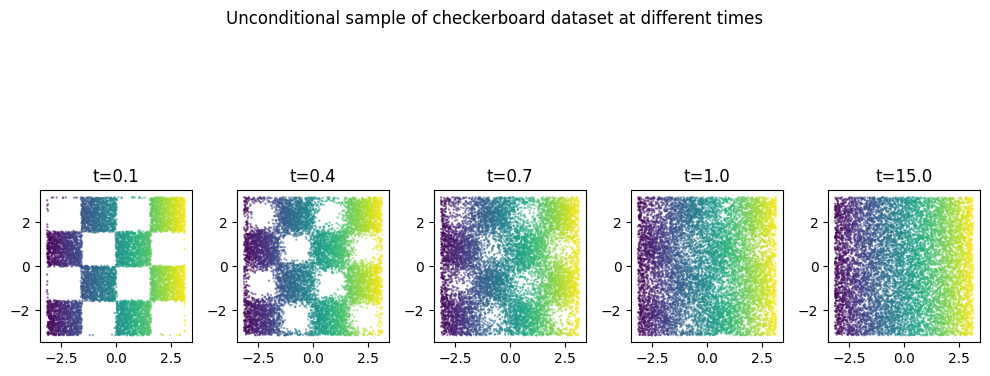

In [30]:
# extract the first sample of the unconditional samples
# post-process the unconditional samples to get the noised theta1 and theta2
fts_1st_list = []
vts_1st_list = []
theta1_noise_1st_list = []
theta2_noise_1st_list = []
scores_1st_list = []
for ti in range(len(constant_t_forward)):
    vts_ti = unconditional_samples[ti][0]
    fts_ti = unconditional_samples[ti][1]
    fts_1st_ti = fts_ti[0]
    vts_1st_ti = vts_ti[0]
    scores_1st_ti = scores[ti][0]
    theta1_noise_ti = fts_1st_ti[:,0]
    theta2_noise_ti = fts_1st_ti[:,1]
    fts_1st_list.append(fts_1st_ti)
    vts_1st_list.append(vts_1st_ti)
    theta1_noise_1st_list.append(theta1_noise_ti)
    theta2_noise_1st_list.append(theta2_noise_ti)
    scores_1st_list.append(scores_1st_ti)
    if i == 0:
        print("shape of vts",vts_ti.shape)
        print("shape of fts",fts_ti.shape)
        print("shape of score",scores_1st_ti.shape)
        print("shape of fts of the first sample",fts_1st_ti.shape)
        print("shape of vts of the first sample",vts_1st_ti.shape)
        # check the max and min of fts
        print("max of noised theta1 of the first sample",fts_1st_ti[:,0].max())
        print("min of noised theta1 of the first sample",fts_1st_ti[:,0].min())

# plot the unconditional sample for each constant t
fig,ax = plt.subplots(1,len(constant_t_forward),figsize=(10,5))
for i in range(len(constant_t_forward)):
    
    # plot the unconditional sample
    ax[i].scatter(theta1_noise_1st_list[i],theta2_noise_1st_list[i],c=theta1_noise_1st_list[i],cmap = "viridis",s = 0.5,alpha = 0.5)
    # ax.set_xlim(-np.pi,np.pi)
    # ax.set_ylim(-np.pi,np.pi)
    ax[i].set_aspect("equal")
    ax[i].set_title("t=" + str(constant_t_forward[i]))
fig.suptitle("Unconditional sample of checkerboard dataset at different times") 
plt.tight_layout()
plt.show()

## Check the score of the forward process at exact time t

torch.Size([1000, 2])
tensor(3.1392)
tensor(-3.1323)


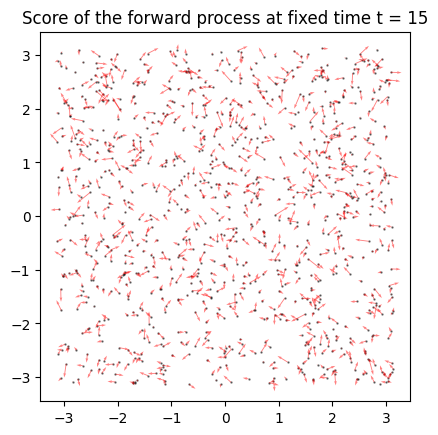

In [41]:
# Test on the smaller dataset
n_points = 1000
batch_size = 32
checkerboard_dataset = Checkerboard_Dataset(n_rows, n_points)
Lie_dataset = TorusLieWrapper(checkerboard_dataset)
Angle_dataset = AngleTorusWrapper(Lie_dataset)
data_loader_small = DataLoader(Angle_dataset, batch_size=batch_size, shuffle = True)

batched_sample = next(iter(data_loader_small))

fixed_t = 15
# sample the forward process at fixed time
model = diffusion.TDMDiffusion(dim = 2, integrator_type = "Euler")
unconditional_sample, score = model.sample_forward(f0 = batched_sample, total_time = 10,t_dist_kw = "constant", constant_t = fixed_t)

vts_batched = unconditional_sample[0]
fts_batched = unconditional_sample[1]
fts_1st = fts_batched[0]
print(fts_1st.shape)
vts_1st = vts_batched[0]
scores_1st = score[0]
theta1_noise_1st = fts_1st[:,0]
theta2_noise_1st = fts_1st[:,1]
print(max(theta1_noise_1st))
print(min(theta1_noise_1st))
# plot the score of the forward process at fixed time

fig,ax = plt.subplots()
ax.scatter(theta1_noise_1st,theta2_noise_1st,c="black",s = 0.5,alpha = 0.5)
ax.quiver(theta1_noise_1st,theta2_noise_1st,scores_1st[:,0],scores_1st[:,1],color = "red",alpha = 0.5)
ax.set_aspect("equal")
ax.set_title("Score of the forward process at fixed time t = " + str(fixed_t))
plt.show()

